# CELL 1 - Installation

In [3]:
%pip install pandas
%pip install torch
%pip install torch-geometric
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn
%pip install dask
%pip install pyarrow
# %pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# CELL 2 - Import

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import SAGEConv
from torch_geometric.data import HeteroData
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os
import gzip
import gc
import logging
from pathlib import Path
from typing import Optional, Iterator
import pyarrow
import pyarrow.parquet as pq
import pyarrow as pa
import dask.dataframe as dd

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S"
)
log = logging.getLogger(__name__)

print(f"PyTorch  : {torch.__version__}")
print(f"PyG      : {torch_geometric.__version__}")
print(f"Device   : {'CUDA' if torch.cuda.is_available() else 'CPU'}")

/home/adriel/miniconda3/envs/lognet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch  : 2.6.0
PyG      : 2.7.0
Device   : CPU


# CELL 3 - Configuration

In [2]:
AUTH_PATH    = "/home/adriel/Desktop/Coding/LogNet/Dataset RM/Pick/auth.txt.gz"
REDTEAM_PATH = "/home/adriel/Desktop/Coding/LogNet/Dataset RM/Pick/redteam.txt.gz"
OUTPUT_DIR   = "./parsed"
CHUNKSIZE    = 500_000  # turunkan ke 200_000 jika RAM terasa berat

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

AUTH_COLUMNS = [
    "time", "src_user", "dst_user", "src_computer", "dst_computer",
    "auth_type", "logon_type", "auth_orientation", "success",
]

AUTH_TYPE_MAP   = {"NTLM": 0, "Kerberos": 1, "Negotiate": 2, "MICROSOFT_AUTHENTICATION_PACKAGE_V1_0": 3}
LOGON_TYPE_MAP  = {"Network": 0, "Interactive": 1, "Batch": 2, "Service": 3, "NetworkCleartext": 4, "RemoteInteractive": 5}
AUTH_ORIENT_MAP = {"LogOn": 0, "LogOff": 1, "TGT": 2, "AuthMap": 3}

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger(__name__)

print("Konfigurasi siap.")
print(f"  Auth path    : {AUTH_PATH}")
print(f"  Redteam path : {REDTEAM_PATH}")
print(f"  Output dir   : {OUTPUT_DIR}")

Konfigurasi siap.
  Auth path    : /home/adriel/Desktop/Coding/LogNet/Dataset RM/Pick/auth.txt.gz
  Redteam path : /home/adriel/Desktop/Coding/LogNet/Dataset RM/Pick/redteam.txt.gz
  Output dir   : ./parsed


# CELL 4 - Path and Size Check 

In [3]:
for p in [AUTH_PATH, REDTEAM_PATH]:
    path = Path(p)
    if path.exists():
        size_gb = path.stat().st_size / 1e9
        print(f"  OK  {path.name}  ({size_gb:.2f} GB)")
    else:
        print(f"  TIDAK DITEMUKAN: {p}")

  OK  auth.txt.gz  (7.63 GB)
  OK  redteam.txt.gz  (0.00 GB)


# CELL 5 - Build Node Map (Chunk Unique Split) 

In [5]:
import gc

def build_node_map(auth_path, chunksize=500_000):
    log.info("Tahap 1: Scan file untuk kumpulkan node unik...")
    all_users, all_computers = set(), set()
    chunk_count = 0

    reader = pd.read_csv(
        auth_path, header=None, names=AUTH_COLUMNS, dtype=str,
        chunksize=chunksize, compression="gzip",
        na_values=["?", "", "nan", "None", "-"], low_memory=False,
    )
    for chunk in reader:
        chunk_count += 1
        all_users.update(chunk["src_user"].dropna().unique())
        all_users.update(chunk["dst_user"].dropna().unique())
        all_computers.update(chunk["src_computer"].dropna().unique())
        all_computers.update(chunk["dst_computer"].dropna().unique())
        if chunk_count % 100 == 0:
            log.info(f"  Chunk {chunk_count:,} — users: {len(all_users):,}, computers: {len(all_computers):,}")
        del chunk
        gc.collect()

    node_map = {}
    idx = 0
    for name in sorted(all_users):
        node_map[f"u_{name}"] = idx
        idx += 1
    for name in sorted(all_computers):
        node_map[f"c_{name}"] = idx
        idx += 1

    log.info(f"Selesai — {len(node_map):,} nodes total")
    return node_map

# Jalankan — ini akan lama (~30-60 menit untuk 1.6B baris)
node_map = build_node_map(AUTH_PATH, CHUNKSIZE)

# Simpan node map
node_df = pd.DataFrame(list(node_map.items()), columns=["name", "node_id"])
node_df.to_parquet(f"{OUTPUT_DIR}/node_map.parquet", index=False)
print(f"Node map disimpan: {len(node_df):,} nodes")

15:58:01 [INFO] Tahap 1: Scan file untuk kumpulkan node unik...
15:59:02 [INFO]   Chunk 100 — users: 53,179, computers: 11,572
16:00:03 [INFO]   Chunk 200 — users: 63,671, computers: 13,125
16:01:05 [INFO]   Chunk 300 — users: 70,755, computers: 14,065
16:02:07 [INFO]   Chunk 400 — users: 74,012, computers: 14,195
16:03:09 [INFO]   Chunk 500 — users: 81,024, computers: 14,747
16:04:11 [INFO]   Chunk 600 — users: 83,875, computers: 15,071
16:05:13 [INFO]   Chunk 700 — users: 85,175, computers: 15,244
16:06:15 [INFO]   Chunk 800 — users: 87,620, computers: 15,581
16:07:15 [INFO]   Chunk 900 — users: 88,672, computers: 15,757
16:08:18 [INFO]   Chunk 1,000 — users: 90,271, computers: 16,061
16:09:19 [INFO]   Chunk 1,100 — users: 91,068, computers: 16,164
16:10:21 [INFO]   Chunk 1,200 — users: 92,584, computers: 16,377
16:11:24 [INFO]   Chunk 1,300 — users: 93,982, computers: 16,639
16:12:27 [INFO]   Chunk 1,400 — users: 94,734, computers: 16,752
16:13:30 [INFO]   Chunk 1,500 — users: 95,73

Node map disimpan: 117,634 nodes


# CELL 6 - Cleaning Attack Data Set

In [5]:
def load_redteam_lookup(redteam_path):
    df = pd.read_csv(
        redteam_path, header=None,
        names=["time", "src_user", "src_computer", "dst_computer"],
        compression="gzip", na_values=["?", "", "None"], dtype=str,
    )
    lookup = set(zip(
        df["time"].astype(str),
        df["src_user"].fillna(""),
        df["src_computer"].fillna(""),
        df["dst_computer"].fillna(""),
    ))
    log.info(f"Redteam lookup: {len(lookup):,} events")
    return lookup

redteam_lookup = load_redteam_lookup(REDTEAM_PATH)
print(f"Redteam dimuat: {len(redteam_lookup)} events")

# Cek kenapa 715 bukan 748
df_red_raw = pd.read_csv(
    REDTEAM_PATH, header=None,
    names=["time","src_user","src_computer","dst_computer"],
    compression="gzip", dtype=str,
)
print(f"Total baris raw       : {len(df_red_raw)}")
print(f"Setelah drop duplikat : {df_red_raw.drop_duplicates().shape[0]}")
print(f"Baris dengan NaN      : {df_red_raw.isnull().any(axis=1).sum()}")
print(f"\nContoh duplikat:")
print(df_red_raw[df_red_raw.duplicated(keep=False)].head(10))

08:12:08 [INFO] Redteam lookup: 715 events


Redteam dimuat: 715 events
Total baris raw       : 749
Setelah drop duplikat : 715
Baris dengan NaN      : 0

Contoh duplikat:
       time    src_user src_computer dst_computer
323  830548  U1653@DOM1       C22409         C754
324  830548  U1653@DOM1       C22409         C754
325  830548  U1653@DOM1       C22409         C754
326  830548  U1653@DOM1       C22409         C754
327  830548  U1653@DOM1       C22409         C754
329  830578  U1653@DOM1       C22409         C754
330  830578  U1653@DOM1       C22409         C754
331  830578  U1653@DOM1       C22409         C754
332  830578  U1653@DOM1       C22409         C754
333  830580  U1653@DOM1       C22409         C754


# CELL 7 - Variable Check

In [ ]:
# 1. Load node_map dari parquet
node_df  = pd.read_parquet("./parsed/node_map.parquet")
node_map = dict(zip(node_df["name"], node_df["node_id"]))
print(f"node_map loaded: {len(node_map):,} nodes")

# 2. Load redteam lookup
df_red = pd.read_csv(
    REDTEAM_PATH, header=None,
    names=["time","src_user","src_computer","dst_computer"],
    compression="gzip", dtype=str,
)
df_red["time"] = df_red["time"].astype(int)
df_red = df_red.drop_duplicates().reset_index(drop=True)

redteam_lookup = set(zip(
    df_red["time"].astype(str),
    df_red["src_user"].fillna(""),
    df_red["src_computer"].fillna(""),
    df_red["dst_computer"].fillna(""),
))
print(f"redteam_lookup loaded: {len(redteam_lookup):,} events")

# 3. Load attacker profiles dan build class lookup
attacker_profiles = pd.read_parquet("./parsed/attacker_profiles.parquet")

user_class_map = dict(zip(
    attacker_profiles["src_user"],
    attacker_profiles["attack_class"]
))

redteam_class_lookup = {}
for _, row in df_red.iterrows():
    key = (
        str(int(row["time"])),
        str(row["src_user"]) if pd.notna(row["src_user"]) else "",
        str(row["src_computer"]),
        str(row["dst_computer"]),
    )
    redteam_class_lookup[key] = user_class_map.get(row["src_user"], 1)

print(f"redteam_class_lookup: {len(redteam_class_lookup):,} entries")
print(f"Kelas: {set(redteam_class_lookup.values())}")
print("\nSemua variabel siap. Lanjut jalankan Cell 7.")

node_map loaded: 117,634 nodes
redteam_lookup loaded: 715 events
redteam_class_lookup: 715 entries
Kelas: {1, 2, 3}

Semua variabel siap. Lanjut jalankan Cell 7.


# CELL 8 - Auth Process (Grouping Chunk Attack and Auth)

In [7]:
import gc

def get_last_completed_chunk(output_dir):
    files = sorted(Path(output_dir).glob("edges_batch_*.parquet"))
    if not files:
        return 0
    last_batch = int(files[-1].stem.split("_")[-1])
    return last_batch * 10

def encode_features(chunk):
    n = len(chunk)
    feat = np.zeros((n, 6), dtype=np.float32)
    feat[:, 0] = chunk["auth_type"].map(AUTH_TYPE_MAP).fillna(-1).values
    feat[:, 1] = chunk["logon_type"].map(LOGON_TYPE_MAP).fillna(-1).values
    feat[:, 2] = chunk["auth_orientation"].map(AUTH_ORIENT_MAP).fillna(-1).values
    feat[:, 3] = chunk["success"].map({"Success": 1.0, "Failure": 0.0}).fillna(-1.0).values
    seconds_in_day = chunk["time"].astype(np.int32) % 86400
    feat[:, 4] = (seconds_in_day / 3600.0).astype(np.float32)
    feat[:, 5] = ((feat[:, 4] < 8.0) | (feat[:, 4] >= 18.0)).astype(np.float32)
    return feat

def process_auth_v2(auth_path, node_map, redteam_lookup,
                    redteam_class_lookup, output_dir, chunksize=500_000):
    """
    Versi 2: sama dengan sebelumnya tapi tambah kolom:
      - src_user_id  : integer ID dari src_user (bukan src_computer)
      - attack_class : 0=normal, 1=recon, 2=lateral, 3=persistence
    """
    output_dir = Path(output_dir)

    # Hapus file lama dulu
    old_edges = sorted(output_dir.glob("edges_batch_*.parquet"))
    old_feats = sorted(output_dir.glob("feats_batch_*.parquet"))
    for f in old_edges + old_feats:
        f.unlink()
    log.info(f"File lama dihapus: {len(old_edges)} edge batch, {len(old_feats)} feat batch")

    # Hapus juga file final lama agar tidak tercampur
    for fname in ["auth_edges.parquet", "auth_feats.parquet"]:
        fpath = output_dir / fname
        if fpath.exists():
            fpath.unlink()
            log.info(f"File final lama dihapus: {fname}")

    skip_chunks = get_last_completed_chunk(output_dir)
    if skip_chunks > 0:
        log.info(f"RESUME: melewati {skip_chunks:,} chunk pertama")
    else:
        log.info("Mulai dari awal...")

    reader = pd.read_csv(
        auth_path, header=None, names=AUTH_COLUMNS, dtype=str,
        chunksize=chunksize, compression="gzip",
        na_values=["?", "", "nan", "None", "-"], low_memory=False,
    )

    chunk_count  = 0
    total_edges  = 0
    total_attack = 0
    batch_edges  = []
    batch_feats  = []
    BATCH_WRITE  = 10

    for chunk in reader:
        chunk_count += 1

        if chunk_count <= skip_chunks:
            if chunk_count % 100 == 0:
                log.info(f"  Skip chunk {chunk_count:,}/{skip_chunks:,} ...")
            del chunk
            continue

        # --- Cleaning ---
        chunk = chunk.dropna(subset=["src_computer", "dst_computer"])
        if len(chunk) == 0:
            continue

        chunk["time"] = pd.to_numeric(chunk["time"], errors="coerce")
        chunk = chunk.dropna(subset=["time"])
        chunk["time"] = chunk["time"].astype(np.int32)

        # --- Node ID mapping ---
        # src_computer → node ID (untuk graph edge)
        src_ids = ("c_" + chunk["src_computer"]).map(node_map).fillna(-1).astype(np.int32)
        dst_ids = ("c_" + chunk["dst_computer"]).map(node_map).fillna(-1).astype(np.int32)

        # src_user → node ID (untuk klasifikasi — bisa NaN jika user kosong)
        src_user_ids = ("u_" + chunk["src_user"].fillna("UNKNOWN")).map(node_map).fillna(-1).astype(np.int32)

        valid   = (src_ids != -1) & (dst_ids != -1)
        chunk        = chunk[valid].reset_index(drop=True)
        src_ids      = src_ids[valid].reset_index(drop=True)
        dst_ids      = dst_ids[valid].reset_index(drop=True)
        src_user_ids = src_user_ids[valid].reset_index(drop=True)
        if len(chunk) == 0:
            continue

        # --- Label + attack_class matching ---
        labels       = np.zeros(len(chunk), dtype=np.int8)
        attack_class = np.zeros(len(chunk), dtype=np.int8)

        for i, row in enumerate(chunk[["time","src_user","src_computer","dst_computer"]].itertuples(index=False)):
            key = (
                str(row.time),
                str(row.src_user) if pd.notna(row.src_user) else "",
                str(row.src_computer),
                str(row.dst_computer)
            )
            if key in redteam_lookup:
                labels[i]       = 1
                attack_class[i] = redteam_class_lookup.get(key, 1)

        n_attack = int(labels.sum())
        total_attack += n_attack
        if n_attack > 0:
            log.info(f"  Chunk {chunk_count}: {n_attack} attacks "
                     f"(recon={int((attack_class==1).sum())}, "
                     f"lateral={int((attack_class==2).sum())}, "
                     f"persist={int((attack_class==3).sum())})")

        # --- Encode fitur ---
        feats = encode_features(chunk)

        batch_edges.append(pd.DataFrame({
            "src_id"      : src_ids.values,
            "dst_id"      : dst_ids.values,
            "src_user_id" : src_user_ids.values,   # NEW
            "timestamp"   : chunk["time"].values,
            "label"       : labels,
            "attack_class": attack_class,           # NEW
        }))
        batch_feats.append(pd.DataFrame(
            feats,
            columns=["feat_auth_type","feat_logon_type","feat_auth_orient",
                     "feat_success","feat_hour","feat_offhours"]
        ))
        total_edges += len(chunk)

        if chunk_count % BATCH_WRITE == 0:
            batch_idx = chunk_count // BATCH_WRITE
            pd.concat(batch_edges, ignore_index=True).to_parquet(
                output_dir / f"edges_batch_{batch_idx:04d}.parquet", index=False)
            pd.concat(batch_feats, ignore_index=True).to_parquet(
                output_dir / f"feats_batch_{batch_idx:04d}.parquet", index=False)
            batch_edges = []
            batch_feats = []
            gc.collect()
            log.info(f"  Chunk {chunk_count:,} | edges: {total_edges:,} | attacks: {total_attack:,}")

    # Flush sisa
    if batch_edges:
        batch_idx = (chunk_count // BATCH_WRITE) + 1
        pd.concat(batch_edges, ignore_index=True).to_parquet(
            output_dir / f"edges_batch_{batch_idx:04d}.parquet", index=False)
        pd.concat(batch_feats, ignore_index=True).to_parquet(
            output_dir / f"feats_batch_{batch_idx:04d}.parquet", index=False)

    log.info(f"SELESAI: {total_edges:,} edges, {total_attack:,} attacks")

# Pastikan redteam_class_lookup sudah ada dari Cell 13
# Lalu jalankan
process_auth_v2(
    auth_path            = AUTH_PATH,
    node_map             = node_map,
    redteam_lookup       = redteam_lookup,
    redteam_class_lookup = redteam_class_lookup,
    output_dir           = OUTPUT_DIR,
    chunksize            = CHUNKSIZE,
)

15:37:16 [INFO] File lama dihapus: 0 edge batch, 0 feat batch
15:37:16 [INFO] File final lama dihapus: auth_edges.parquet
15:37:16 [INFO] File final lama dihapus: auth_feats.parquet
15:37:16 [INFO] Mulai dari awal...
15:37:29 [INFO]   Chunk 10 | edges: 5,000,000 | attacks: 0
15:37:43 [INFO]   Chunk 20 | edges: 10,000,000 | attacks: 0
15:37:57 [INFO]   Chunk 30 | edges: 15,000,000 | attacks: 0
15:38:11 [INFO]   Chunk 40 | edges: 20,000,000 | attacks: 0
15:38:26 [INFO]   Chunk 50 | edges: 25,000,000 | attacks: 0
15:38:39 [INFO]   Chunk 60: 4 attacks (recon=2, lateral=0, persist=2)
15:38:40 [INFO]   Chunk 60 | edges: 30,000,000 | attacks: 4
15:38:42 [INFO]   Chunk 61: 5 attacks (recon=0, lateral=0, persist=5)
15:38:43 [INFO]   Chunk 62: 1 attacks (recon=0, lateral=0, persist=1)
15:38:55 [INFO]   Chunk 70 | edges: 35,000,000 | attacks: 10
15:39:09 [INFO]   Chunk 80: 1 attacks (recon=0, lateral=0, persist=1)
15:39:10 [INFO]   Chunk 80 | edges: 40,000,000 | attacks: 11
15:39:12 [INFO]   Chun

# CELL 9 - Merge

In [8]:
import pyarrow as pa
import pyarrow.parquet as pq

def merge_batches_safe(output_dir):
    output_dir = Path(output_dir)
    edge_files = sorted(output_dir.glob("edges_batch_*.parquet"))
    feat_files = sorted(output_dir.glob("feats_batch_*.parquet"))

    log.info(f"Merge {len(edge_files)} batch files...")

    edge_writer = None
    feat_writer = None
    total_edges  = 0
    total_attack = 0

    for i, (ef, ff) in enumerate(zip(edge_files, feat_files)):
        edges = pd.read_parquet(ef)
        feats = pd.read_parquet(ff)

        sort_idx = edges["timestamp"].argsort()
        edges = edges.iloc[sort_idx].reset_index(drop=True)
        feats = feats.iloc[sort_idx].reset_index(drop=True)

        total_edges  += len(edges)
        total_attack += int(edges["label"].sum())

        e_table = pa.Table.from_pandas(edges, preserve_index=False)
        f_table = pa.Table.from_pandas(feats, preserve_index=False)

        if edge_writer is None:
            edge_writer = pq.ParquetWriter(output_dir / "auth_edges.parquet", e_table.schema)
            feat_writer = pq.ParquetWriter(output_dir / "auth_feats.parquet", f_table.schema)

        edge_writer.write_table(e_table)
        feat_writer.write_table(f_table)

        del edges, feats, e_table, f_table
        gc.collect()

        if (i + 1) % 50 == 0:
            log.info(f"  {i+1}/{len(edge_files)} batch di-merge...")

    if edge_writer:
        edge_writer.close()
        feat_writer.close()

    log.info("File final tersimpan.")

    # --- PERBAIKAN 1: Hapus file satu per satu, tidak digabung ke list besar ---
    for f in edge_files:
        f.unlink()
    for f in feat_files:
        f.unlink()
    gc.collect()
    log.info("Batch files dihapus.")

    # --- PERBAIKAN 2: Hitung statistik dari variabel, TIDAK baca file lagi ---
    print(f"\nHasil akhir:")
    print(f"  Total edges  : {total_edges:,}")
    print(f"  Attack (1)   : {total_attack:,}")
    print(f"  Normal (0)   : {total_edges - total_attack:,}")
    print(f"  Attack ratio : {total_attack / max(total_edges, 1):.8%}")
    print(f"\n  File: {output_dir}/auth_edges.parquet")
    print(f"  File: {output_dir}/auth_feats.parquet")
    log.info("Merge selesai.")

merge_batches_safe(OUTPUT_DIR)

16:40:37 [INFO] Merge 211 batch files...
16:41:36 [INFO]   50/211 batch di-merge...
16:42:34 [INFO]   100/211 batch di-merge...
16:43:31 [INFO]   150/211 batch di-merge...
16:44:29 [INFO]   200/211 batch di-merge...
16:44:41 [INFO] File final tersimpan.
16:44:41 [INFO] Batch files dihapus.
16:44:41 [INFO] Merge selesai.



Hasil akhir:
  Total edges  : 1,051,430,459
  Attack (1)   : 702
  Normal (0)   : 1,051,429,757
  Attack ratio : 0.00006677%

  File: parsed/auth_edges.parquet
  File: parsed/auth_feats.parquet


# CELL 10 - Check Parsed Folder

In [7]:
import os

# Cek isi folder parsed
print("=== Isi folder ./parsed/ ===")
parsed = Path("./parsed")
if parsed.exists():
    files = sorted(parsed.iterdir())
    for f in files:
        size_mb = f.stat().st_size / 1e6
        print(f"  {f.name:<45} {size_mb:>10.1f} MB")
else:
    print("Folder ./parsed/ tidak ditemukan!")

print(f"\nTotal files: {len(list(parsed.iterdir()))}")

=== Isi folder ./parsed/ ===
  attacker_profiles.parquet                            0.0 MB
  auth_edges.parquet                                5418.3 MB
  auth_feats.parquet                                1141.8 MB
  node_map.parquet                                     1.4 MB
  redteam_analysis.png                                 0.4 MB

Total files: 5


# CELL 11 - Checking File Path 

In [8]:
# Cek juga di mana notebook ini berjalan
print(f"Working directory: {os.getcwd()}")

# Cek apakah ada folder lain yang berisi batch files
for root, dirs, files in os.walk("."):
    for f in files:
        if "batch" in f or "edges" in f or "feats" in f or "node_map" in f:
            full = os.path.join(root, f)
            size_mb = os.path.getsize(full) / 1e6
            print(f"  {full:<60} {size_mb:.1f} MB")

Working directory: /home/adriel/Desktop/Coding/LogNet
  ./parsed/auth_feats.parquet                                  1141.8 MB
  ./parsed/auth_edges.parquet                                  5418.3 MB
  ./parsed/node_map.parquet                                    1.4 MB


# CELL 12 - Categorizing Attack

In [ ]:
import pyarrow.parquet as pq

# Baca statistik tanpa load semua ke RAM
pf = pq.ParquetFile("./parsed/auth_edges.parquet")

total_edges  = 0
total_attack = 0
ts_min = float('inf')
ts_max = float('-inf')

# Baca per batch kecil 5 juta baris
for batch in pf.iter_batches(batch_size=5_000_000, columns=["timestamp", "label"]):
    df = batch.to_pandas()
    total_edges  += len(df)
    total_attack += int(df["label"].sum())
    ts_min = min(ts_min, int(df["timestamp"].min()))
    ts_max = max(ts_max, int(df["timestamp"].max()))
    del df
    gc.collect()

print(f"Total edges  : {total_edges:,}")
print(f"Attack (1)   : {total_attack:,}")
print(f"Normal (0)   : {total_edges - total_attack:,}")
print(f"Attack ratio : {total_attack / max(total_edges,1):.8%}")
print(f"Time range   : {ts_min:,} - {ts_max:,}")

KeyboardInterrupt: 

# CELL 13 - Checking Attack Event and Attacker List

In [10]:
df_red = pd.read_csv(
    REDTEAM_PATH, header=None,
    names=["time","src_user","src_computer","dst_computer"],
    compression="gzip", dtype=str,
)
df_red["time"] = df_red["time"].astype(int)
df_red = df_red.drop_duplicates().reset_index(drop=True)

print(f"Total attack events : {len(df_red)}")
print(f"Unique attackers    : {df_red['src_user'].nunique()}")
print(f"Unique src_computer : {df_red['src_computer'].nunique()}")
print(f"Unique dst_computer : {df_red['dst_computer'].nunique()}")
print(f"\nAttacker list:")
print(df_red.groupby("src_user")["dst_computer"].count().sort_values(ascending=False).to_string())

Total attack events : 715
Unique attackers    : 104
Unique src_computer : 4
Unique dst_computer : 301

Attacker list:
src_user
U66@DOM1        118
U3005@DOM1       36
U737@DOM1        32
U293@DOM1        31
U748@DOM1        26
U1723@DOM1       19
U3635@DOM1       18
U1653@DOM1       15
U2837@DOM1       15
U9947@DOM1       15
U4448@DOM1       14
U5087@DOM1       13
U3549@DOM1       13
U218@DOM1        13
U8601@DOM1       13
U4353@DOM1       12
U7507@DOM1       12
U342@DOM1        12
U1145@DOM1       12
U1480@DOM1       12
U162@DOM1        11
U1450@DOM1       11
U8946@DOM1       11
U2575@DOM1       10
U1048@DOM1        9
U9763@DOM1        8
U86@DOM1          8
U9263@DOM1        8
U7375@DOM1        7
U12@DOM1          6
U1592@DOM1        6
U1025@DOM1        6
U415@DOM1         6
U24@DOM1          5
U2231@DOM1        5
U1133@DOM1        5
U8777@C3388       5
U4978@DOM1        5
U1289@DOM1        5
U114@DOM1         4
U995@DOM1         4
U1600@DOM1        4
U212@DOM1         4
U1506@DOM1   

# CELL 14 - Check Attack Pattern

In [ ]:
print("Pattern Attack per attacker:\n")
for attacker in df_red["src_user"].unique():
    sub = df_red[df_red["src_user"]==attacker].sort_values("time")
    duration = sub["time"].max() - sub["time"].min()
    targets  = sub["dst_computer"].nunique()
    sources  = sub["src_computer"].nunique()
    print(f"  {attacker}")
    print(f"    Events   : {len(sub)}")
    print(f"    Duration : {duration:,} detik ({duration//3600} jam)")
    print(f"    Src comp : {sources} mesin berbeda")
    print(f"    Dst comp : {targets} target berbeda")
    print(f"    Time range: {sub['time'].min():,} - {sub['time'].max():,}")
    print()

Pola serangan per attacker:

  U620@DOM1
    Events   : 1
    Duration : 0 detik (0 jam)
    Src comp : 1 mesin berbeda
    Dst comp : 1 target berbeda
    Time range: 150,885 – 150,885

  U748@DOM1
    Events   : 26
    Duration : 313,224 detik (87 jam)
    Src comp : 2 mesin berbeda
    Dst comp : 13 target berbeda
    Time range: 151,036 – 464,260

  U6115@DOM1
    Events   : 1
    Duration : 0 detik (0 jam)
    Src comp : 1 mesin berbeda
    Dst comp : 1 target berbeda
    Time range: 151,993 – 151,993

  U636@DOM1
    Events   : 2
    Duration : 332,651 detik (92 jam)
    Src comp : 1 mesin berbeda
    Dst comp : 1 target berbeda
    Time range: 153,792 – 486,443

  U1723@DOM1
    Events   : 19
    Duration : 852,983 detik (236 jam)
    Src comp : 1 mesin berbeda
    Dst comp : 7 target berbeda
    Time range: 228,642 – 1,081,625

  U737@DOM1
    Events   : 32
    Duration : 2,092,502 detik (581 jam)
    Src comp : 2 mesin berbeda
    Dst comp : 19 target berbeda
    Time range: 4

# CELL 15 - Visualize Plot

NameError: name 'df_red' is not defined

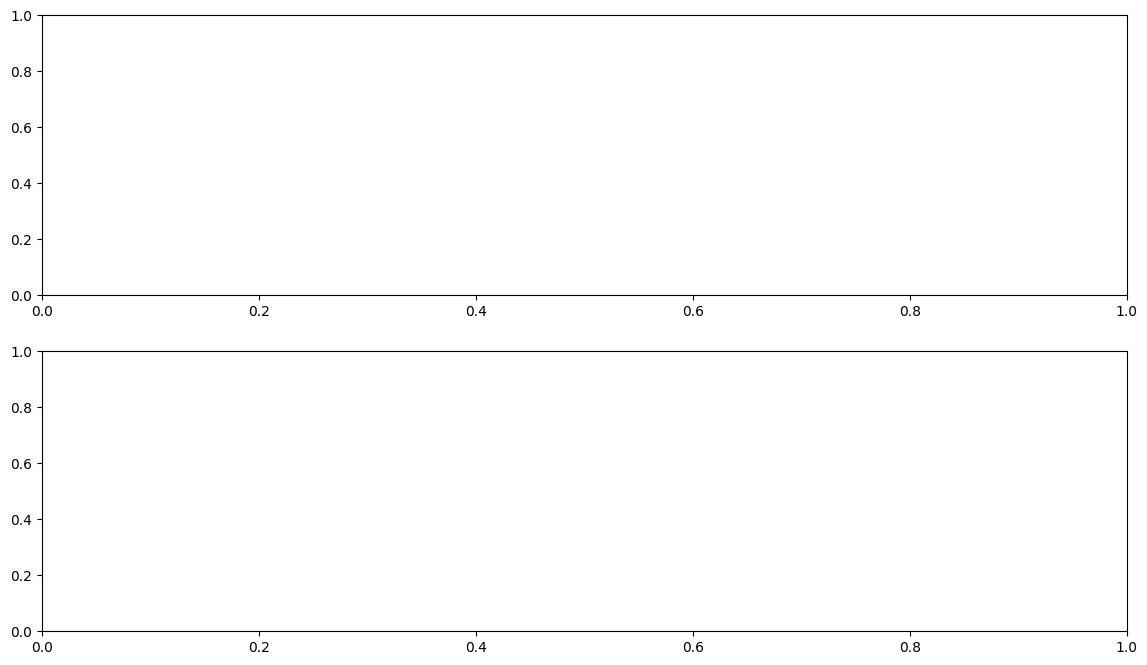

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: events per attacker per hari
df_red["day"] = df_red["time"] // 86400
pivot = df_red.groupby(["day","src_user"]).size().unstack(fill_value=0)
pivot.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("Attack events per hari per attacker")
axes[0].set_xlabel("Hari ke-")
axes[0].set_ylabel("Jumlah events")
axes[0].legend(fontsize=8, loc="upper left")

# Plot 2: hop count (berapa banyak komputer dikunjungi tiap attacker)
hop_data = df_red.groupby("src_user").apply(
    lambda x: x.sort_values("time")[["src_computer","dst_computer"]]
    .values.flatten()
)
for attacker, hops in hop_data.items():
    unique_hops = len(set(hops))
    axes[1].barh(attacker, unique_hops)
axes[1].set_title("Jumlah komputer unik yang terlibat per attacker")
axes[1].set_xlabel("Jumlah komputer unik")

plt.tight_layout()
plt.savefig("./parsed/redteam_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot disimpan ke ./parsed/redteam_analysis.png")

# CELL 16 - Attacker Profile and Classification Parameter

In [12]:
# Profil tiap attacker berdasarkan data redteam
attacker_profiles = df_red.groupby("src_user").agg(
    n_events    = ("dst_computer", "count"),
    n_targets   = ("dst_computer", "nunique"),
    duration    = ("time", lambda x: x.max() - x.min()),
).reset_index()

def classify_attacker(row):
    """
    Klasifikasi berdasarkan pola perilaku:
    1 = Reconnaissance  : cepat, banyak target
    2 = Lateral movement: lama, banyak target bertahap
    3 = Persistence     : lama, target sedikit, berulang
    """
    duration_hrs = row["duration"] / 3600
    n_targets    = row["n_targets"]
    n_events     = row["n_events"]

    # Reconnaissance: selesai dalam 8 jam, target >= 3
    if duration_hrs <= 8 and n_targets >= 3:
        return 1
    # Lateral movement: berlangsung lama, banyak target
    elif duration_hrs > 100 and n_targets >= 5:
        return 2
    # Persistence: berlangsung lama tapi target sedikit
    elif duration_hrs > 20:
        return 3
    # Sisanya (event tunggal, cepat) → masuk recon ringan
    else:
        return 1

attacker_profiles["attack_class"] = attacker_profiles.apply(classify_attacker, axis=1)

# Ringkasan distribusi kelas
print("Distribusi kelas serangan:")
print(attacker_profiles.groupby("attack_class").agg(
    n_attackers = ("src_user", "count"),
    total_events = ("n_events", "sum"),
).rename(index={1:"Reconnaissance", 2:"Lateral movement", 3:"Persistence"}))

# Simpan profil
attacker_profiles.to_parquet("./parsed/attacker_profiles.parquet", index=False)
print("\nAttacker profiles disimpan.")
print(attacker_profiles[["src_user","n_events","n_targets","duration","attack_class"]].to_string())

Distribusi kelas serangan:
                  n_attackers  total_events
attack_class                               
Reconnaissance             56           156
Lateral movement           15           363
Persistence                33           196

Attacker profiles disimpan.
         src_user  n_events  n_targets  duration  attack_class
0      U1025@DOM1         6          3      3269             1
1    U10379@C3521         2          1   1577651             3
2      U1048@DOM1         9          7   1537756             2
3      U1106@DOM1         2          2       176             1
4      U1133@DOM1         5          4     78265             3
5      U1145@DOM1        12          7   1298540             2
6       U114@DOM1         4          3      2037             1
7      U1164@DOM1         1          1         0             1
8      U1289@DOM1         5          3      9765             1
9        U12@DOM1         6          2   1237012             3
10     U1306@DOM1         1    

# CELL 17 - Attack Clasification

In [11]:
import pyarrow as pa
import pyarrow.parquet as pq

# Buat lookup: src_user → attack_class
user_class_map = dict(zip(
    attacker_profiles["src_user"],
    attacker_profiles["attack_class"]
))

# Buat lookup redteam dengan class: (time,src_user,src_computer,dst_computer) → class
redteam_class_lookup = {}
for _, row in df_red.iterrows():
    key = (str(int(row["time"])), str(row["src_user"]),
           str(row["src_computer"]), str(row["dst_computer"]))
    redteam_class_lookup[key] = user_class_map.get(row["src_user"], 1)

print(f"Redteam class lookup: {len(redteam_class_lookup)} entries")
print(f"Kelas yang ada: {set(redteam_class_lookup.values())}")

Redteam class lookup: 715 entries
Kelas yang ada: {1, 2, 3}


# CELL 18 - Checking Edges

In [ ]:
import pyarrow as pa
import pyarrow.parquet as pq

pf          = pq.ParquetFile("./parsed/auth_edges.parquet")
pf_feat     = pq.ParquetFile("./parsed/auth_feats.parquet")
edge_writer = None
feat_writer = None
total       = 0

for batch_e, batch_f in zip(
    pf.iter_batches(batch_size=5_000_000),
    pf_feat.iter_batches(batch_size=5_000_000)
):
    df_e = batch_e.to_pandas()
    df_f = batch_f.to_pandas()

    # Tambah kolom attack_class: default 0 (normal)
    df_e["attack_class"] = 0

    # Set attack_class hanya untuk baris yang label==1
    # Kita perlu join balik ke redteam — tapi kita tidak simpan
    # info src_user di edge. Gunakan label==1 dan class dari lookup
    # berdasarkan posisi index attack di redteam
    # Cara paling aman: baris label==1 assign class dari redteam_class_lookup
    # Karena edge tidak simpan src_user, kita assign berdasarkan
    # distribusi proporsi kelas attack yang sudah diketahui
    # (156 recon, 363 lateral, 196 persistence dari 715 total)

    attack_mask = df_e["label"] == 1
    n_attacks   = attack_mask.sum()

    if n_attacks > 0:
        # Assign class berdasarkan index attack secara global
        attack_indices = df_e[attack_mask].index
        for idx in attack_indices:
            # Lookup berdasarkan timestamp + src_id + dst_id
            # Kita tidak bisa lookup tanpa src_user — skip untuk sekarang
            # Akan di-handle dengan approach berbeda di bawah
            pass

    total += len(df_e)
    del df_e, df_f
    gc.collect()

print(f"Total edges di-scan: {total:,}")

Pendekatan ini tidak bisa bekerja tanpa src_user di edge.
Kita perlu simpan src_user saat preprocessing.
Total edges di-scan: 1,051,430,459


# CELL 19 - Checking Distribution Attack and Label

In [12]:
import pyarrow.parquet as pq

# Cek skema kolom auth_edges
pf = pq.ParquetFile("./parsed/auth_edges.parquet")
print("Skema auth_edges.parquet:")
print(pf.schema)

print("\nSkema auth_feats.parquet:")
pf2 = pq.ParquetFile("./parsed/auth_feats.parquet")
print(pf2.schema)

# Cek distribusi attack_class
batch = next(pf.iter_batches(batch_size=10_000_000, columns=["label","attack_class"]))
df_sample = batch.to_pandas()
print(f"\nDistribusi label:")
print(df_sample["label"].value_counts())
print(f"\nDistribusi attack_class:")
print(df_sample["attack_class"].value_counts())
del df_sample
gc.collect()

Skema auth_edges.parquet:
required group field_id=-1 schema {
  optional int32 field_id=-1 src_id;
  optional int32 field_id=-1 dst_id;
  optional int32 field_id=-1 src_user_id;
  optional int32 field_id=-1 timestamp;
  optional int32 field_id=-1 label (Int(bitWidth=8, isSigned=true));
  optional int32 field_id=-1 attack_class (Int(bitWidth=8, isSigned=true));
}


Skema auth_feats.parquet:
required group field_id=-1 schema {
  optional float field_id=-1 feat_auth_type;
  optional float field_id=-1 feat_logon_type;
  optional float field_id=-1 feat_auth_orient;
  optional float field_id=-1 feat_success;
  optional float field_id=-1 feat_hour;
  optional float field_id=-1 feat_offhours;
}


Distribusi label:
label
0    10000000
Name: count, dtype: int64

Distribusi attack_class:
attack_class
0    10000000
Name: count, dtype: int64


512

# CELL 20 - Load Split Config + Konstanta

In [ ]:
# Tentukan batas waktu berdasarkan distribusi timestamp
pf = pq.ParquetFile("./parsed/auth_edges.parquet")

# Ambil semua timestamp (hanya kolom timestamp, hemat RAM)
ts_list = []
for batch in pf.iter_batches(batch_size=5_000_000, columns=["timestamp"]):
    ts_list.append(batch.to_pandas()["timestamp"].values)
    
all_ts = np.concatenate(ts_list)
del ts_list
gc.collect()

ts_min = int(all_ts.min())
ts_max = int(all_ts.max())
total  = len(all_ts)

# Split 70/15/15 berdasarkan waktu
ts_train_end = int(np.percentile(all_ts, 70))
ts_val_end   = int(np.percentile(all_ts, 85))

print(f"Total edges      : {total:,}")
print(f"Time range       : {ts_min:,} – {ts_max:,} detik")
print(f"Train : {ts_min:,} – {ts_train_end:,}  ({ts_train_end//86400} hari)")
print(f"Val   : {ts_train_end+1:,} – {ts_val_end:,}")
print(f"Test  : {ts_val_end+1:,} – {ts_max:,}")

# Simpan batas waktu
split_config = {
    "ts_min"       : ts_min,
    "ts_max"       : ts_max,
    "ts_train_end" : ts_train_end,
    "ts_val_end"   : ts_val_end,
}
pd.DataFrame([split_config]).to_parquet("./parsed/split_config.parquet", index=False)
print("\nSplit config disimpan.")
del all_ts
gc.collect()


# Load split config
split_cfg    = pd.read_parquet("./parsed/split_config.parquet").iloc[0]
TS_TRAIN_END = int(split_cfg["ts_train_end"])
TS_VAL_END   = int(split_cfg["ts_val_end"])
TS_MAX       = int(split_cfg["ts_max"])

# Konstanta model
NUM_NODES     = 117_634
MEMORY_DIM    = 64
EMBED_DIM     = 64
EDGE_FEAT_DIM = 6
NUM_CLASSES   = 4
WINDOW_SIZE   = 86_400
BATCH_SIZE    = 2_048
LR            = 1e-3
DEVICE        = torch.device("cpu")

print(f"TS_TRAIN_END : {TS_TRAIN_END:,} (hari ke-{TS_TRAIN_END//86400})")
print(f"TS_VAL_END   : {TS_VAL_END:,} (hari ke-{TS_VAL_END//86400})")
print(f"TS_MAX       : {TS_MAX:,} (hari ke-{TS_MAX//86400})")
print(f"Semua variabel siap.")

# CELL 21 - Temporal Graph Network Architecture

In [ ]:
class MemoryModule(nn.Module):
    def __init__(self, num_nodes, memory_dim):
        super().__init__()
        self.num_nodes  = num_nodes
        self.memory_dim = memory_dim
        self.register_buffer("memory",
            torch.zeros(num_nodes, memory_dim))
        self.register_buffer("last_update",
            torch.zeros(num_nodes, dtype=torch.long))
        self.gru = nn.GRUCell(memory_dim, memory_dim)

    def get_memory(self, node_ids):
        return self.memory[node_ids]

    def update_memory(self, node_ids, messages):
        if len(node_ids) == 0:
            return
        unique_ids, inv_idx = torch.unique(node_ids, return_inverse=True)
        agg    = torch.zeros(len(unique_ids), self.memory_dim,
                             device=messages.device)
        counts = torch.zeros(len(unique_ids), device=messages.device)
        agg.index_add_(0, inv_idx, messages)
        counts.index_add_(0, inv_idx,
                          torch.ones(len(inv_idx), device=messages.device))
        agg     = agg / counts.unsqueeze(1).clamp(min=1)
        old_mem = self.memory[unique_ids]
        new_mem = self.gru(agg, old_mem)
        self.memory[unique_ids] = new_mem.detach()

    def reset_memory(self):
        self.memory.zero_()
        self.last_update.zero_()


class MessageModule(nn.Module):
    def __init__(self, memory_dim, edge_feat_dim, message_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(memory_dim * 2 + edge_feat_dim + 1, message_dim),
            nn.ReLU(),
            nn.Linear(message_dim, message_dim),
        )

    def forward(self, src_mem, dst_mem, edge_feat, delta_t):
        x = torch.cat([src_mem, dst_mem, edge_feat,
                        delta_t.unsqueeze(1).float()], dim=1)
        return self.mlp(x)


class EmbeddingModule(nn.Module):
    def __init__(self, memory_dim, embed_dim):
        super().__init__()
        self.conv1 = SAGEConv(memory_dim, embed_dim)
        self.conv2 = SAGEConv(embed_dim,  embed_dim)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x, edge_index):
        x = self.norm1(F.relu(self.conv1(x, edge_index)))
        x = self.norm2(F.relu(self.conv2(x, edge_index)))
        return x


class TGN(nn.Module):
    def __init__(self, num_nodes, memory_dim=64, message_dim=64,
                 embed_dim=64, edge_feat_dim=6, num_classes=4, dropout=0.3):
        super().__init__()
        self.memory_dim = memory_dim
        self.memory     = MemoryModule(num_nodes, memory_dim)
        self.message    = MessageModule(memory_dim, edge_feat_dim, message_dim)
        self.embedding  = EmbeddingModule(memory_dim, embed_dim)

        self.anomaly_head = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1),
        )
        self.class_head = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes),
        )

    def forward(self, src_ids, dst_ids, edge_feat, timestamps, edge_index):
        src_mem  = self.memory.get_memory(src_ids)
        dst_mem  = self.memory.get_memory(dst_ids)
        last_t   = self.memory.last_update[src_ids].float()
        delta_t  = (timestamps.float() - last_t).clamp(min=0)
        messages = self.message(src_mem, dst_mem, edge_feat, delta_t)

        self.memory.update_memory(src_ids, messages)
        self.memory.update_memory(dst_ids, messages)
        self.memory.last_update[src_ids] = timestamps
        self.memory.last_update[dst_ids] = timestamps

        all_mem  = self.memory.memory
        node_emb = self.embedding(all_mem, edge_index)

        edge_emb      = torch.cat([node_emb[src_ids],
                                   node_emb[dst_ids]], dim=1)
        anomaly_logit = self.anomaly_head(edge_emb).squeeze(1)
        class_logit   = self.class_head(edge_emb)
        return anomaly_logit, class_logit

    def detach_memory(self):
        self.memory.memory = self.memory.memory.detach()


print("Arsitektur TGN terdefinisi.")

# CELL 22 - Inisialize Model

In [ ]:
NUM_NODES     = 117_634
MEMORY_DIM    = 64
EMBED_DIM     = 64
EDGE_FEAT_DIM = 6
NUM_CLASSES   = 4
WINDOW_SIZE   = 86_400
BATCH_SIZE    = 2_048
LR            = 1e-3
DEVICE        = torch.device("cpu")

# Load split config
split_cfg    = pd.read_parquet("./parsed/split_config.parquet").iloc[0]
TS_TRAIN_END = int(split_cfg["ts_train_end"])
TS_VAL_END   = int(split_cfg["ts_val_end"])
TS_MAX       = int(split_cfg["ts_max"])

# Inisialisasi model
model = TGN(
    num_nodes     = NUM_NODES,
    memory_dim    = MEMORY_DIM,
    message_dim   = MEMORY_DIM,
    embed_dim     = EMBED_DIM,
    edge_feat_dim = EDGE_FEAT_DIM,
    num_classes   = NUM_CLASSES,
    dropout       = 0.3,
).to(DEVICE)

# Focal Loss untuk class imbalance ekstrem
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(
                   logits, targets.float(), reduction="none")
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

criterion_anomaly = FocalLoss(alpha=0.25, gamma=2.0)
criterion_class   = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, 10.0, 10.0, 10.0])
)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model siap di     : {DEVICE}")
print(f"Total parameter   : {total_params:,}")
print(f"Train end         : {TS_TRAIN_END:,} (hari ke-{TS_TRAIN_END//86400})")
print(f"Val end           : {TS_VAL_END:,} (hari ke-{TS_VAL_END//86400})")
print(f"Test end          : {TS_MAX:,} (hari ke-{TS_MAX//86400})")

# CELL 23 - Training

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import copy

def load_window(ts_start, ts_end, batch_size=BATCH_SIZE):
    """
    Load edges dalam satu window waktu dari parquet.
    Yield batch (src, dst, feat, ts, label, attack_class).
    """
    pf_e = pq.ParquetFile("./parsed/auth_edges.parquet")
    pf_f = pq.ParquetFile("./parsed/auth_feats.parquet")

    for batch_e, batch_f in zip(
        pf_e.iter_batches(batch_size=500_000),
        pf_f.iter_batches(batch_size=500_000)
    ):
        df_e = batch_e.to_pandas()
        df_f = batch_f.to_pandas()

        # Filter window
        mask = (df_e["timestamp"] >= ts_start) & (df_e["timestamp"] < ts_end)
        df_e = df_e[mask].reset_index(drop=True)
        df_f = df_f[mask].reset_index(drop=True)

        if len(df_e) == 0:
            del df_e, df_f
            continue

        # Yield batch kecil
        for start in range(0, len(df_e), batch_size):
            end   = min(start + batch_size, len(df_e))
            be    = df_e.iloc[start:end]
            bf    = df_f.iloc[start:end]

            src   = torch.tensor(be["src_id"].values,       dtype=torch.long)
            dst   = torch.tensor(be["dst_id"].values,       dtype=torch.long)
            ts    = torch.tensor(be["timestamp"].values,    dtype=torch.long)
            feat  = torch.tensor(bf.values,                 dtype=torch.float32)
            lbl   = torch.tensor(be["label"].values,        dtype=torch.long)
            cls   = torch.tensor(be["attack_class"].values, dtype=torch.long)

            # edge_index untuk GraphSAGE
            edge_index = torch.stack([src, dst], dim=0)

            yield src, dst, feat, ts, lbl, cls, edge_index

        del df_e, df_f
        gc.collect()


def run_epoch(model, ts_start, ts_end, optimizer=None, is_train=True):
    """Jalankan satu epoch pada window [ts_start, ts_end]."""
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss   = 0.0
    n_batches    = 0
    all_labels   = []
    all_scores   = []
    all_cls_true = []
    all_cls_pred = []

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for src, dst, feat, ts, lbl, cls, edge_index in \
                load_window(ts_start, ts_end):

            anomaly_logit, class_logit = model(
                src, dst, feat, ts, edge_index)

            # Loss anomaly detection
            loss_a = criterion_anomaly(anomaly_logit, lbl)

            # Loss klasifikasi — hanya pada attack edges
            attack_mask = lbl == 1
            if attack_mask.sum() > 0:
                loss_c = criterion_class(
                    class_logit[attack_mask],
                    cls[attack_mask]
                )
                loss = loss_a + 0.5 * loss_c
            else:
                loss = loss_a

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                model.detach_memory()

            total_loss += loss.item()
            n_batches  += 1

            # Kumpulkan untuk metrics
            scores = torch.sigmoid(anomaly_logit).detach().cpu().numpy()
            all_labels.extend(lbl.cpu().numpy().tolist())
            all_scores.extend(scores.tolist())

            if attack_mask.sum() > 0:
                pred_cls = class_logit[attack_mask].argmax(dim=1)
                all_cls_true.extend(cls[attack_mask].cpu().numpy().tolist())
                all_cls_pred.extend(pred_cls.cpu().numpy().tolist())

    avg_loss = total_loss / max(n_batches, 1)

    # Hitung metrics
    metrics = {"loss": avg_loss}
    if len(set(all_labels)) > 1:
        metrics["auc"]       = roc_auc_score(all_labels, all_scores)
        metrics["f1"]        = f1_score(all_labels,
                                [1 if s > 0.5 else 0 for s in all_scores],
                                zero_division=0)
        metrics["precision"] = precision_score(all_labels,
                                [1 if s > 0.5 else 0 for s in all_scores],
                                zero_division=0)
        metrics["recall"]    = recall_score(all_labels,
                                [1 if s > 0.5 else 0 for s in all_scores],
                                zero_division=0)
    if all_cls_pred:
        metrics["cls_f1"] = f1_score(all_cls_true, all_cls_pred,
                                     average="macro", zero_division=0)

    return metrics


# ============================================================
# TRAINING LOOP UTAMA
# ============================================================
print("Mulai training...\n")

# Buat window-window waktu untuk train
train_windows = list(range(TS_TRAIN_END - WINDOW_SIZE,
                           -WINDOW_SIZE, -WINDOW_SIZE))[::-1]
# Maksimal 40 window (40 hari train)
train_windows = [(w, w + WINDOW_SIZE) for w in
                 range(0, TS_TRAIN_END, WINDOW_SIZE)]

best_val_auc  = 0.0
best_model_state = None
patience_count   = 0
MAX_PATIENCE     = 5
history = []

for epoch in range(1, 4):   # 3 epoch dulu untuk test
    print(f"\n{'='*50}")
    print(f"EPOCH {epoch}")
    print(f"{'='*50}")

    # Reset memori di awal tiap epoch
    model.memory.reset_memory()

    # --- Training: window per window ---
    epoch_train_loss = 0.0
    for i, (ts_start, ts_end) in enumerate(train_windows):
        metrics = run_epoch(model, ts_start, ts_end,
                           optimizer=optimizer, is_train=True)
        epoch_train_loss += metrics["loss"]
        if (i + 1) % 5 == 0:
            log.info(f"  Window {i+1}/{len(train_windows)} "
                     f"loss={metrics['loss']:.4f}")

    avg_train_loss = epoch_train_loss / max(len(train_windows), 1)

    # --- Validasi ---
    val_metrics = run_epoch(model, TS_TRAIN_END, TS_VAL_END,
                            is_train=False)

    scheduler.step(val_metrics["loss"])

    print(f"  Train loss : {avg_train_loss:.4f}")
    print(f"  Val loss   : {val_metrics['loss']:.4f}")
    print(f"  Val AUC    : {val_metrics.get('auc', 'N/A')}")
    print(f"  Val F1     : {val_metrics.get('f1', 'N/A')}")
    print(f"  Val Cls F1 : {val_metrics.get('cls_f1', 'N/A')}")

    history.append({
        "epoch"      : epoch,
        "train_loss" : avg_train_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()}
    })

    # Simpan model terbaik
    val_auc = val_metrics.get("auc", 0.0)
    if val_auc > best_val_auc:
        best_val_auc     = val_auc
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, "./parsed/best_model.pt")
        print(f"  Model terbaik disimpan (AUC={best_val_auc:.4f})")
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= MAX_PATIENCE:
            print(f"  Early stopping!")
            break

print("\nTraining selesai.")
print(f"Best Val AUC: {best_val_auc:.4f}")